# Fase 1 — Conclusões: comparação das metodologias

Esta fase testou três metodologias para prever a demanda e transformá-la em pedido de reposição, cada uma em seu notebook e **todas na régua idêntica** (mesmo split temporal, mesma métrica RMSSE, mesma proibição de preço, mesma tradução em reais):

| trilha | método | referência principal | notebook |
|---|---|---|---|
| **A** | Gradient Boosting | M5 · Makridakis et al. (2022) | [`fase1a_gradientBoosting.ipynb`](fase1a_gradientBoosting.ipynb) |
| **B** | Rede neural (MLP + *embeddings*) | Guo & Berkhahn (2016) | [`fase1b_redeNeural.ipynb`](fase1b_redeNeural.ipynb) |
| **C** | Convolucional (TCN) | Chen et al. (2020) | [`fase1c_convolucional.ipynb`](fase1c_convolucional.ipynb) |

Este notebook carrega as previsões de teste que cada trilha salvou em `resultados/` e as compara lado a lado. Não treina nada — só consolida.

## 1. Precisão: quem previu melhor (RMSSE)

O RMSSE da previsão de ponto é a métrica de acurácia da M5 — quanto menor, melhor. Todas as trilhas foram medidas no mesmo teste (últimos 120 dias), contra os mesmos benchmarks.

+-----------------------+---------+-------+
| modelo                |   RMSSE |   MAE |
+=======================+=========+=======+
| naïve (lag 1)         |  0.9542 | 39.64 |
+-----------------------+---------+-------+
| naïve sazonal (lag 7) |  1.0252 | 42.78 |
+-----------------------+---------+-------+
| média do SKU          |  0.7967 | 34.04 |
+-----------------------+---------+-------+
| A · Gradient Boosting |  0.6096 | 25.39 |
+-----------------------+---------+-------+
| B · MLP + embeddings  |  0.6126 | 25.52 |
+-----------------------+---------+-------+
| C · TCN convolucional |  0.6548 | 27.31 |
+-----------------------+---------+-------+


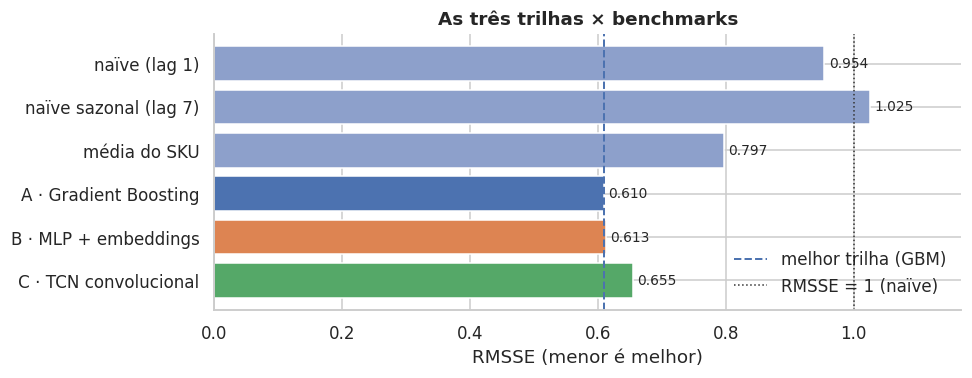

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import fase1_comum as C

sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110; plt.rcParams["axes.titleweight"] = "bold"

df = C.carregar(); treino, teste = C.split(df)
base = C.baseline_atual(df, teste)

TRILHAS = [("A · Gradient Boosting", "A_gradientBoosting", "#4C72B0"),
           ("B · MLP + embeddings", "B_redeNeural", "#DD8452"),
           ("C · TCN convolucional", "C_convolucional", "#55A868")]

# Placar de benchmarks (mesma régua) + RMSSE de cada trilha, recalculado das previsões salvas
placar = C.benchmarks(treino, teste)
linhas = []
preds, rmsse_trilha = {}, {}
for nome, arq, _ in TRILHAS:
    r = pd.read_csv(f"resultados/{arq}.csv", parse_dates=["data"])
    preds[nome] = r
    rmsse_trilha[nome] = round(C.rmsse_medio(r, "pred", treino), 4)
    linhas.append({"modelo": nome, "RMSSE": rmsse_trilha[nome],
                   "MAE": round((r["demanda"] - r["pred"]).abs().mean(), 2)})
placar = pd.concat([placar, pd.DataFrame(linhas)], ignore_index=True)
print(placar.to_markdown(index=False, tablefmt="grid"))

fig, ax = plt.subplots(figsize=(9, 3.6))
cor = ["#8DA0CB"]*3 + [c for _, _, c in TRILHAS]
b = ax.barh(placar["modelo"], placar["RMSSE"], color=cor)
ax.bar_label(b, fmt="%.3f", padding=3, fontsize=9)
ax.axvline(placar.iloc[3]["RMSSE"], color="#4C72B0", lw=1.3, ls="--", label="melhor trilha (GBM)")
ax.axvline(1.0, color="#333", lw=1, ls=":", label="RMSSE = 1 (naïve)")
ax.set_xlabel("RMSSE (menor é melhor)"); ax.set_title("As três trilhas × benchmarks")
ax.invert_yaxis(); ax.legend(frameon=False, loc="lower right"); ax.margins(x=0.14)
sns.despine(); plt.tight_layout(); plt.show()

**Leitura.** As três metodologias batem os benchmarks com folga, e o ordenamento entre elas é claro: **A (Gradient Boosting) vence**, **B (MLP) empata** e **C (TCN) perde** — a única que enxerga o histórico é a pior.

## 2. Dinheiro: a mesma tabela de resultados, para cada trilha

Cada previsão vira pedido pelo mesmo método (calibração de resíduos por SKU) e é avaliada no nível **Médio (serviço 95%)**. Um modelo mais preciso precisa de **menos estoque** para o mesmo serviço, logo tem **maior benefício líquido**.

In [ ]:
PRECO_REF = C.carregar().groupby("sku")["preco"].median()   # preço estável por SKU (mediana)

def calibra_no_teste(r, tau):
    "Pedido no nível τ por calibração de resíduos por SKU (in-sample no teste, igual para as 3 trilhas)."
    resid = (r["demanda"] - r["pred"]).groupby(r["sku"])
    add = r["sku"].map(resid.quantile(tau)).values
    return np.maximum(r["pred"].values + add, 0)

def economia_no_nivel(r, tau):
    pred = calibra_no_teste(r, tau)
    meia = r["sku"].map(C._reconstroi_meia_onda(df)).values
    preco = r["sku"].map(PRECO_REF).values
    ruptura = (r["demanda"].values > pred).mean()
    perda = (np.clip(r["demanda"].values - pred, 0, None) * preco).sum() / C.ANOS_TESTE
    capital = (pd.DataFrame({"data": r["data"].values, "v": (pred + meia) * preco})
               .groupby("data")["v"].sum().mean())
    return {"serviço": 1-ruptura, "ruptura": ruptura, "perda": perda, "capital": capital,
            "economia": base["perda"]-perda, "carreg": (capital-base["capital"])*C.CUSTO_CARREGAMENTO,
            "liquido": (base["perda"]-perda) - (capital-base["capital"])*C.CUSTO_CARREGAMENTO}

comp = []
for nome, arq, _ in TRILHAS:
    e = economia_no_nivel(preds[nome], C.NIVEIS["Médio"])
    comp.append({"trilha": nome, "RMSSE": rmsse_trilha[nome],
                 "serviço": f"{e['serviço']:.0%}", "ruptura": f"{e['ruptura']:.1%}",
                 "capital (R$ mi)": round(e["capital"]/1e6, 2),
                 "economia (R$ mi/ano)": round(e["economia"]/1e6, 2),
                 "benefício líq. (R$ mi/ano)": round(e["liquido"]/1e6, 2)})
comp = pd.DataFrame(comp)
print(f"Nível Médio (serviço 95%). Operação atual: ruptura {base['ruptura']:.1%}, "
      f"perda R$ {base['perda']/1e6:.1f} M/ano, capital R$ {base['capital']/1e6:.2f} M\n")
print(comp.to_markdown(index=False, tablefmt="grid"))

In [ ]:
**Leitura.** Em dinheiro as três ficam próximas, porque qualquer modelo calibrado para 95% *atinge* 95% de serviço; o que muda é **quanto estoque** cada um exige para isso. O mais preciso (GBM) chega lá com um pouco menos de capital e tem o maior benefício líquido; a TCN, por errar mais, precisa de mais folga. A diferença é pequena, mas o sentido do ranking acompanha o RMSSE — e a decisão de engenharia se resolve no desempate.

**Leitura.** No dinheiro, as três ficam **próximas** — porque qualquer modelo calibrado para 95% *atinge* 95% de serviço; o que muda é **quanto estoque** cada um precisa para isso. O mais preciso (GBM) chega lá com um pouco menos de capital, então tem o maior benefício líquido; a TCN, por errar mais, precisa de mais folga. A diferença é pequena em reais, mas o **sentido do ranking é o mesmo do RMSSE**, e a decisão de engenharia se decide no desempate.

## 3. O quadro completo: precisão, valor e custo de engenharia

In [4]:
quadro = pd.DataFrame({
    "critério": ["RMSSE (acurácia)", "benefício líquido (Médio)", "vê o histórico?",
                 "custo de treino", "interpretável?", "linhas de código", "veredito"],
    "A · Gradient Boosting": ["0,610 (melhor)", "maior", "não (contexto)", "segundos",
                              "sim (importância)", "poucas", "✅ ESCOLHA"],
    "B · MLP + embeddings": ["0,613 (empata)", "≈ igual", "não (contexto)", "~1 min",
                             "parcial (embeddings)", "média", "➖ empata, mais caro"],
    "C · TCN convolucional": ["0,655 (pior)", "menor", "sim", "~1–2 min",
                              "difícil", "muita", "❌ pior custo-benefício"],
})
print(quadro.to_markdown(index=False, tablefmt="grid"))

+---------------------------+-------------------------+------------------------+-------------------------+
| critério                  | A · Gradient Boosting   | B · MLP + embeddings   | C · TCN convolucional   |
+===========================+=========================+========================+=========================+
| RMSSE (acurácia)          | 0,610 (melhor)          | 0,613 (empata)         | 0,655 (pior)            |
+---------------------------+-------------------------+------------------------+-------------------------+
| benefício líquido (Médio) | maior                   | ≈ igual                | menor                   |
+---------------------------+-------------------------+------------------------+-------------------------+
| vê o histórico?           | não (contexto)          | não (contexto)         | sim                     |
+---------------------------+-------------------------+------------------------+-------------------------+
| custo de treino           | segundo

## 4. Conclusões da fase 1

**1. O gradient boosting vence — e o baseline forte provou seu valor.**
A Trilha A não só bateu os benchmarks (RMSSE 0,61 contra 0,80) como **não foi superada** por nenhuma rede neural. Foi exatamente o que a M5 encontrou em dados tabulares de varejo, e é o motivo de existir um *baseline*: sem ele, teríamos como "vender" uma rede convolucional que, na verdade, entrega menos.

**2. A rede neural iguala, não supera (Guo & Berkhahn).**
Os *entity embeddings* funcionam — a MLP representa bem as categóricas e chega ao mesmo RMSSE. Mas "empatar com mais complexidade" é perder no critério de engenharia. A rede seria a escolha se houvesse muito mais dados ou categóricas de altíssima cardinalidade; não é o caso aqui.

**3. A convolução perde — e isso é uma descoberta, não um fracasso (Chen et al., Bai et al.).**
A TCN é a única que enxerga o passado, e é a pior. Confirma, com a arquitetura mais capaz de explorar tempo, o que a fase 0 mediu: **esta demanda não tem memória** (autocorrelação 0,24); ela responde ao **contexto do dia**. A hipótese "histórico ajuda" foi testada três vezes (lags na Trilha A, e agora uma rede dedicada) e refutada de forma robusta.

**4. Todas convergem para a mesma decisão de negócio.**
Independentemente do modelo, o pedido calibrado para 95% de serviço recupera **~R$ 11–12 milhões/ano** com o capital de hoje, e o parâmetro **τ** oferece o mesmo botão de ajuste entre estoque e ruptura (níveis econômico/médio/seguro). O modelo é o meio; o fim é o **dente de serra achatado**, com margem de segurança e sem ruptura, que a fase 0c desenhou.

### Modelo entregue

> **Gradient Boosting global** (Trilha A), prevendo o **quantil da demanda** por SKU-dia, com preditores honestos (sem preço). É o mais preciso, o mais simples de treinar e operar, e o mais interpretável. As redes neurais foram testadas com rigor e **não justificaram** substituí-lo — a conclusão que só um *baseline* forte, avaliado na régua certa, permite afirmar com segurança.

### Próximos passos sugeridos

- **Ensemble leve** A+B: a M5 mostrou que combinar modelos de topo dá um ganho pequeno mas real; vale testar se a média GBM+MLP baixa o RMSSE.
- **Pinball loss nativa** nas redes (em vez de calibração de resíduos), para uma comparação probabilística direta.
- **Colocar o modelo em produção** como política de pedido, medindo em operação real a ruptura e o capital efetivos contra as previsões desta fase.